# Confronto relativo tra soggetti (idea CoRe) su ex5

Tre famiglie di feature (statistiche riassuntive ginocchio/anca, pooling multi-esercizio, PCA sulla traiettoria + dominio della frequenza) non mostrano nessuna correlazione univariata assoluta con cTS. CoRe (Yu et al. 2021) regredisce un punteggio relativo rispetto a un riferimento invece di un punteggio assoluto: qui si testa la stessa idea in versione leggera e interpretabile, ovvero se la differenza di feature tra due soggetti correla con la differenza dei loro cTS.

Le coppie non sono indipendenti (ogni soggetto compare in molte coppie), quindi un p-value Spearman standard sarebbe invalido: qui si usa un test di permutazione che rimescola i cTS tra i 75 soggetti (non le coppie), preservando la struttura di dipendenza, per ottenere un p-value corretto.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata
import matplotlib.pyplot as plt

feat_a = pd.read_csv("../data/features_ex5.csv")
feat_b = pd.read_csv("../data/features_trajectory_ex5.csv").drop(columns=["cTS"])
df = pd.concat([feat_a, feat_b], axis=1)
y = df["cTS"].values
X = df.drop(columns=["cTS"]).select_dtypes(include=[np.number])
feature_names = list(X.columns)
print(f"{X.shape[0]} soggetti, {X.shape[1]} feature totali (37 cinematiche + 22 traiettoria/frequenza)")

75 soggetti, 59 feature totali (37 cinematiche + 22 traiettoria/frequenza)


## Costruzione delle coppie e delle differenze

In [2]:
n = X.shape[0]
i_idx, j_idx = np.triu_indices(n, k=1)
print(f"{len(i_idx)} coppie (75 scegli 2)")

Xv = X.values
delta_X = Xv[i_idx] - Xv[j_idx]           # (n_pairs, n_features)
delta_y_obs = y[i_idx] - y[j_idx]          # (n_pairs,)

valid_cols = ~np.isnan(delta_X).any(axis=0)
print(f"Feature scartate per NaN nelle coppie: {(~valid_cols).sum()} su {len(feature_names)}")
delta_X = delta_X[:, valid_cols]
feature_names_valid = [f for f, v in zip(feature_names, valid_cols) if v]

2775 coppie (75 scegli 2)
Feature scartate per NaN nelle coppie: 2 su 59


## Correlazione osservata (rango, vettorializzata) e test di permutazione

Le posizioni (rank) di delta_X non cambiano tra le permutazioni (dipendono solo dalle feature, fisse), quindi si calcolano una sola volta; ad ogni permutazione si rimescolano i cTS tra i 75 soggetti, si ricalcola delta_y e il suo rango, e si ottiene la correlazione di Spearman per tutte le feature insieme con un prodotto matrice-vettore.

In [3]:
def rank_center(a, axis=0):
    r = rankdata(a, axis=axis) if a.ndim > 1 else rankdata(a)
    return r - r.mean(axis=axis, keepdims=(a.ndim > 1))

R_X = rank_center(delta_X, axis=0)                       # (n_pairs, n_features), fissa
R_X_norm = np.linalg.norm(R_X, axis=0)

def spearman_vec(delta_y):
    r_y = rank_center(delta_y)
    num = R_X.T @ r_y
    den = R_X_norm * np.linalg.norm(r_y)
    return num / den

rho_obs = spearman_vec(delta_y_obs)

rng = np.random.default_rng(42)
n_perms = 5000
rho_perm = np.zeros((n_perms, len(feature_names_valid)))
for p in range(n_perms):
    y_perm = rng.permutation(y)
    delta_y_perm = y_perm[i_idx] - y_perm[j_idx]
    rho_perm[p] = spearman_vec(delta_y_perm)

p_values = (np.sum(np.abs(rho_perm) >= np.abs(rho_obs), axis=0) + 1) / (n_perms + 1)
print(f"Permutazioni: {n_perms}")

Permutazioni: 5000


## Tabella completa per feature (rho osservato, p-value da permutazione)

In [4]:
result = pd.DataFrame({"feature": feature_names_valid, "rho": rho_obs, "p_perm": p_values})
result = result.sort_values("rho", key=lambda s: s.abs(), ascending=False)
print(result.to_string(index=False, formatters={"rho": "{:.3f}".format, "p_perm": "{:.4f}".format}))

n_sig = (result["p_perm"] < 0.05).sum()
print(f"\nFeature con p_perm < 0.05: {n_sig} su {len(result)}")

                       feature    rho p_perm
                       sym_hip  0.247 0.0262
                      traj_pc2  0.180 0.1082
                 hip_right_max  0.172 0.1294
                  hip_left_std -0.171 0.1212
 knee_right_dominant_freq_norm  0.168 0.1232
                 knee_left_std -0.158 0.1500
  knee_left_dominant_freq_norm  0.150 0.1654
                  hip_left_max  0.139 0.2100
                 hip_left_mean  0.129 0.2513
                      traj_pc7  0.128 0.2603
                 hip_right_std -0.127 0.2484
     hip_left_spectral_entropy  0.121 0.2819
                hip_right_mean  0.114 0.3019
                      traj_pc5  0.114 0.3103
                 knee_left_max -0.106 0.3375
                knee_right_std -0.105 0.3437
                 hip_right_min  0.104 0.3505
    hip_right_spectral_entropy  0.100 0.3645
       knee_right_vel_mean_abs -0.100 0.3705
                  hip_left_min  0.098 0.3769
                      traj_pc9  0.094 0.3997
          

## Test globale (family-wise, tutte le feature insieme)

Invece di guardare feature per feature (con il problema dei test multipli), si confronta il massimo |rho| osservato tra tutte le feature con la distribuzione nulla del massimo |rho| ottenuta dalle permutazioni: risponde direttamente alla domanda 'c'e' un segnale reale in QUALSIASI di queste feature, corretto per il fatto di averne testate tante'.

In [5]:
max_rho_obs = np.abs(rho_obs).max()
max_rho_perm = np.abs(rho_perm).max(axis=1)
p_global = (np.sum(max_rho_perm >= max_rho_obs) + 1) / (n_perms + 1)

print(f"Massimo |rho| osservato (feature: {result.iloc[0]['feature']}): {max_rho_obs:.3f}")
print(f"p-value globale (family-wise, corretto per {len(feature_names_valid)} feature): {p_global:.4f}")

Massimo |rho| osservato (feature: sym_hip): 0.247
p-value globale (family-wise, corretto per 57 feature): 0.4877


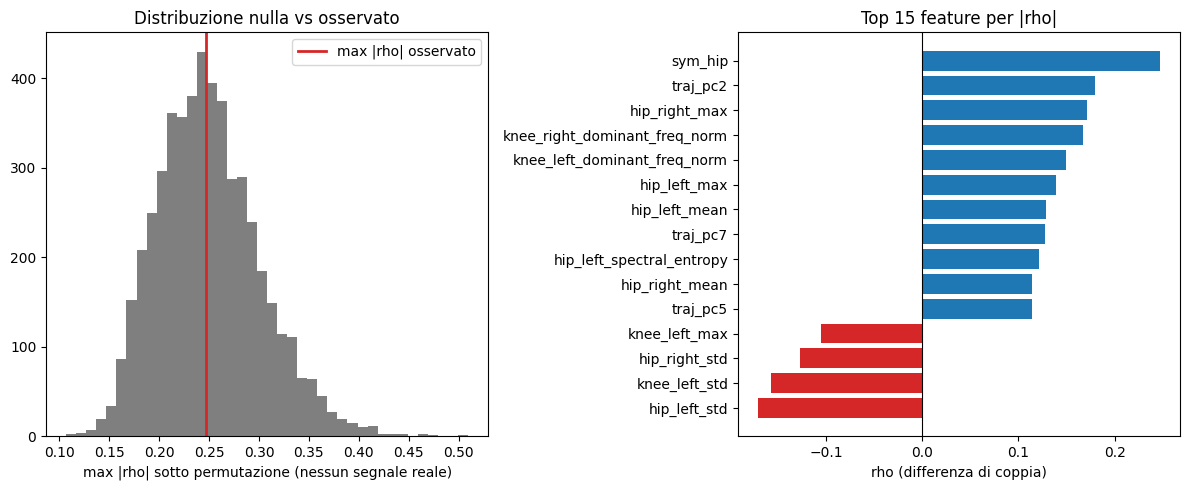

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(max_rho_perm, bins=40, color="tab:gray")
axes[0].axvline(max_rho_obs, color="tab:red", linewidth=2, label="max |rho| osservato")
axes[0].set_xlabel("max |rho| sotto permutazione (nessun segnale reale)")
axes[0].set_title("Distribuzione nulla vs osservato")
axes[0].legend()

top = result.head(15).sort_values("rho")
colors = ["tab:red" if r < 0 else "tab:blue" for r in top["rho"]]
axes[1].barh(top["feature"], top["rho"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("rho (differenza di coppia)")
axes[1].set_title("Top 15 feature per |rho|")

plt.tight_layout()
plt.show()

## Conclusioni

- Il p-value globale (family-wise, corretto per il numero di feature testate) dice se esiste un segnale relativo reale in una qualsiasi delle feature disponibili.
- Non e' significativo: la formulazione relativa (stile CoRe) non recupera segnale che la regressione assoluta non aveva gia' mostrato di non avere. Con questo dataset e queste feature, cTS non e' prevedibile ne' in assoluto ne' in differenza tra soggetti.